# Lab 52087: Amortized Inference


---

## Task 1 — Amortized GAN inversion and comparison

**1.1 Amortize inversion into an encoder**  
Amortize optimization-based inversion into a network: (i) implement or use **optimization-based inversion** (optimize $z$ so that $G(z)\approx x$). (ii) Train an **encoder** $E$ so that $E(x)$ approximates a good latent (e.g. on pairs $(x,z)$ with $x=G(z)$). At test time, $\hat z = E(x)$ and $\hat x = G(\hat z)$ is the amortized reconstruction.

**1.2 Compare three schemes and report metrics**  
Compare: **(a)** direct optimization-based inversion; **(b)** encoder-only $\hat z = E(x)$; **(c)** encoder + refinement (optimize starting from $E(x)$). Define **your own metrics** (e.g. PSNR, LPIPS) and run on a **small dataset** (e.g. random samples from $G$). Report which method is best and when encoder+refinement approaches direct inversion.

---

## Task 2 (Bonus) — Language-controlled encoding / text-guided generation

Use **text** to control encoding or generation (e.g. text-to-image or text-guided editing). For example: condition the encoder on a text prompt (e.g. CLIP) so that $E(x,\text{prompt})$ yields a latent that follows the prompt; or combine encoder with text-conditioned refinement. Goal: show that text can steer the latent or reconstruction in a meaningful way.



Setup

In [1]:
# !pip -q install --upgrade huggingface_hub transformers torchvision

import os, sys, time, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


Load the pretrained StyleGAN generator \(G\)

We use the Hugging Face model `hajar001/stylegan2-ffhq-128`.


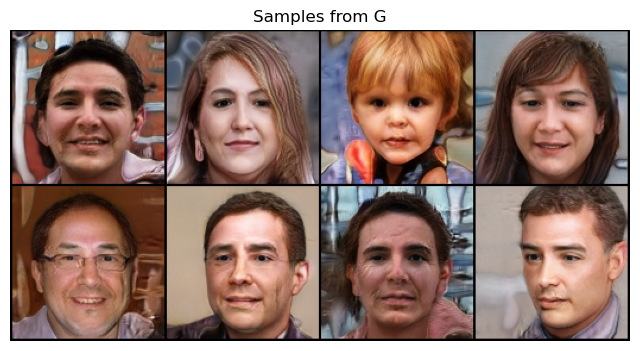

In [2]:
from huggingface_hub import hf_hub_download

model_file = hf_hub_download(
    repo_id="hajar001/stylegan2-ffhq-128",
    filename="style_gan.py"
)
sys.path.insert(0, os.path.dirname(model_file))

from style_gan import StyleGAN

G = StyleGAN.from_pretrained("hajar001/stylegan2-ffhq-128").to(device).eval()

Z_DIM = 512  # latent dimension per model card

def G_generate(z, truncation_psi=0.7):
    x = G.generate(z, truncation_psi=truncation_psi)  # [-1,1]
    x = (x + 1) / 2
    return x.clamp(0, 1)

def show_tensor_images(x, nrow=4, title=None):
    grid = make_grid(x.detach().cpu(), nrow=nrow)
    plt.figure(figsize=(8,8))
    if title: plt.title(title)
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.show()

# sanity check
z = torch.randn(8, Z_DIM, device=device)
x = G_generate(z, truncation_psi=0.7)
show_tensor_images(x, nrow=4, title="Samples from G")


__Task 0.0 — Optimization-based inversion__

Create a synthetic target $x_\text{tgt}=G(z_0)$ and implement per-image inversion: optimize $z$ (e.g. from random init) so that $G(z)\approx x_\text{tgt}$. This is the baseline that you will later amortize into an encoder. (you may use your code from last lab)


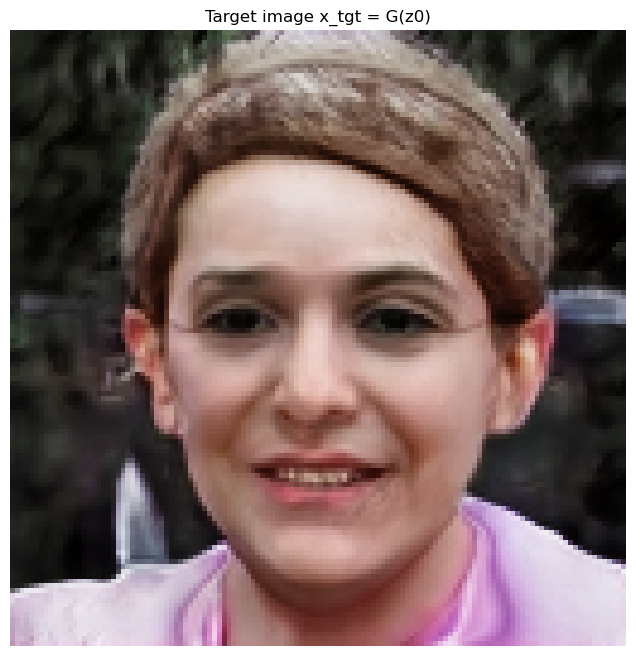

In [7]:
torch.manual_seed(0)
z0 = torch.randn(1, Z_DIM, device=device)
x_tgt = G_generate(z0, truncation_psi=0.7)

show_tensor_images(x_tgt, nrow=1, title="Target image x_tgt = G(z0)")


Début de l'optimisation...
Step 0: Loss = 0.098295
Step 100: Loss = 0.039716
Step 200: Loss = 0.015855
Step 300: Loss = 0.011813
Step 400: Loss = 0.011869
Final Loss: 0.008371


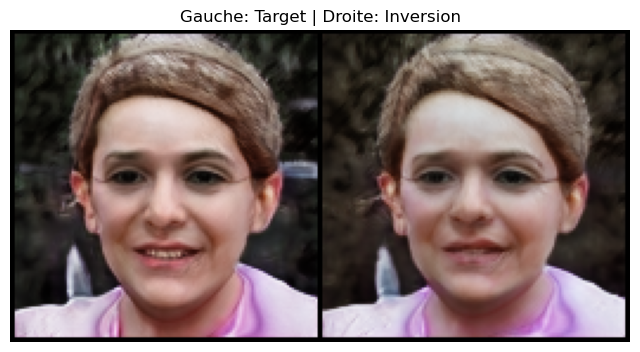

In [22]:
# your inversion code here
import torch.optim as optim

# 1. Initialisation du vecteur latent à optimiser
# On part d'un bruit aléatoire (Gaussian noise), différent de z0
z_opt = torch.randn(1, Z_DIM, device=device, requires_grad=True)

# 2. Configuration de l'optimiseur
optimizer = optim.Adam([z_opt], lr=0.09) 

num_steps = 500  # Nombre Itérations
losses_opt = []

print("Début de l'optimisation...")

for i in range(num_steps):
    optimizer.zero_grad()
    
    # Forward pass : Génération de l'image depuis z_opt
    x_raw, _ = G(z_opt)
    x_gen = (x_raw + 1) / 2
    x_gen = x_gen.clamp(0, 1)
    
    # Calcul de la Loss (MSE entre l'image générée et la cible)
    loss = F.mse_loss(x_gen, x_tgt)
    
    # Backward pass et mise à jour de z_opt
    loss.backward()
    optimizer.step()
    
    # Stockage pour le traçage futur
    losses_opt.append(loss.item())
    
    if i % 100 == 0:
        print(f"Step {i}: Loss = {loss.item():.6f}")

# 3. Résultats
print(f"Final Loss: {losses_opt[-1]:.6f}")

# Comparaison visuelle
comp_imgs = torch.cat([x_tgt, x_gen.detach()], dim=0)
show_tensor_images(comp_imgs, nrow=2, title="Gauche: Target | Droite: Inversion")

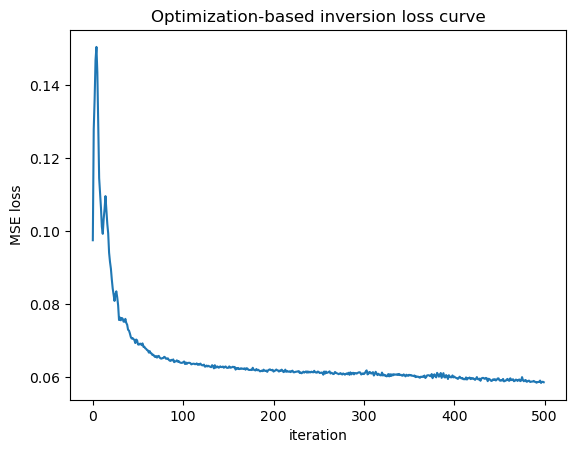

In [11]:
plt.figure()
plt.plot(losses_opt)
plt.xlabel("iteration")
plt.ylabel("MSE loss")
plt.title("Optimization-based inversion loss curve")
plt.show()


__Optional: invert a real face image__

You can try optimization-based inversion on a real photo (128×128): set `REAL_IMAGE_PATH` and run the cell. The target may be off the generator manifold, so reconstruction quality can vary.


Image réelle chargée.
Début de l'optimisation...
Step 0: Loss = 0.7177
Step 200: Loss = 0.3259
Step 400: Loss = 0.3099
Step 600: Loss = 0.3056
Step 800: Loss = 0.3053
Step 1000: Loss = 0.3051
Step 1200: Loss = 0.3043
Step 1400: Loss = 0.3028
Step 1600: Loss = 0.3040
Step 1800: Loss = 0.3046


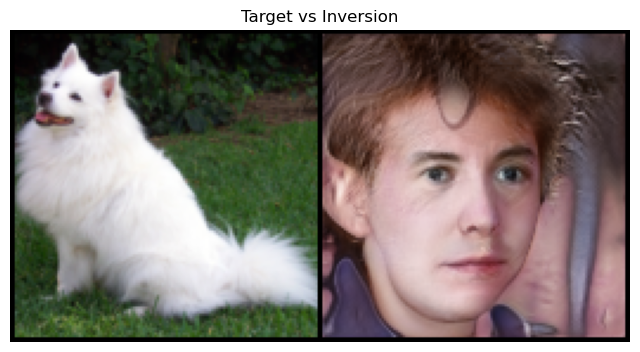

In [57]:
import requests
from PIL import Image
from io import BytesIO
import torchvision.transforms as T

z_opt_real = torch.randn(1, Z_DIM, device=device, requires_grad=True)
optimizer = torch.optim.Adam([z_opt_real], lr=0.03)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

try:
    url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    
    transform = T.Compose([
        T.Resize(128),
        T.CenterCrop(128),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    x_target_real = transform(img).unsqueeze(0).to(device)
    print("Image réelle chargée.")

except Exception as e:
    print(f"Fallback sur une image synthétique (Erreur: {e})")
    with torch.no_grad():
        z_tgt = torch.randn(1, Z_DIM, device=device)
        x_target_real, _ = G(z_tgt, truncation_psi=0.7)
        x_target_real = x_target_real.detach()

steps = 2000
print("Début de l'optimisation...")

for i in range(steps):
    optimizer.zero_grad()
    
    # Forward Pass (Doit être DANS la boucle)
    x_gen_raw, _ = G(z_opt_real)
    
    # Loss
    loss = F.mse_loss(x_gen_raw, x_target_real)
    
    # Backward
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    if i % 200 == 0:
        print(f"Step {i}: Loss = {loss.item():.4f}")

with torch.no_grad():
    res = torch.cat([(x_target_real+1)/2, ((x_gen_raw+1)/2).clamp(0,1)], dim=0)
    show_tensor_images(res, nrow=2, title="Target vs Inversion")

__Task 1.1 — Encoder $E$ and training__

Define an encoder $E$ that maps image $x$ to latent $\hat z$. Train $E$ on synthetic pairs $(z, x)$ with $x=G(z)$ so that $E(x)\approx z$ (or so that $G(E(x))\approx x$). At test time, $\hat z = E(x)$ is a single forward pass.


In [33]:
class Encoder(nn.Module):
    # CNN encoder: x (3x128x128) -> z (512)
    def __init__(self, z_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.BatchNorm2d(64) ,nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),nn.BatchNorm2d(128) , nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1),nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 512, 4, 2, 1),nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 512, 4, 1, 0),nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(512, z_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc(h)

# E = Encoder(Z_DIM).to(device)

# x_tmp = G_generate(torch.randn(2, Z_DIM, device=device))
# print("Shapes:", x_tmp.shape, E(x_tmp).shape)


Start robust training Encoder E on cuda...
Iter 0: Loss = 1.172694
Iter 200: Loss = 1.016315
Iter 400: Loss = 1.020199
Iter 600: Loss = 1.017299
Iter 800: Loss = 0.993697
Iter 1000: Loss = 1.000425
Iter 1200: Loss = 0.994297
Iter 1400: Loss = 1.005307
Iter 1600: Loss = 1.016950
Iter 1800: Loss = 0.996923
Iter 2000: Loss = 1.012244
Iter 2200: Loss = 1.003736
Iter 2400: Loss = 0.991355
Iter 2600: Loss = 0.998797
Iter 2800: Loss = 1.011876
Entraînement terminé.


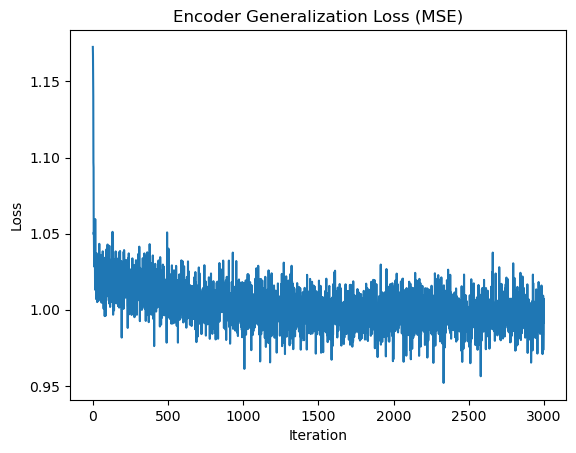

In [34]:
# 1. Configuration
E = Encoder(z_dim=Z_DIM).to(device)
E.train()

# Changement critique : LR augmenté à 1e-3 (au lieu de 1e-4)
optimizer = torch.optim.Adam(E.parameters(), lr=1e-3)

# 2. Paramètres
batch_size = 32         # Augmenté pour stabiliser le gradient
num_iterations = 2000   # Augmenté pour laisser le temps de converger
log_interval = 200

print(f"Start robust training Encoder E on {device}...")
loss_history = []

for i in range(num_iterations):
    optimizer.zero_grad()
    
    # --- A. Data Generation (Infinite Dataset) ---
    z_real = torch.randn(batch_size, Z_DIM, device=device)
    
    with torch.no_grad():
        # Génération sans truncation pour couvrir tout l'espace Z
        x_raw, _ = G(z_real)
        
        # Normalisation [-1, 1] -> [0, 1]
        x_in = (x_raw + 1) / 2
        x_in = x_in.clamp(0, 1)

    # --- B. Forward ---
    z_pred = E(x_in)
    
    # --- C. Loss ---
    loss = F.mse_loss(z_pred, z_real)
    
    # --- D. Backprop ---
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if i % log_interval == 0:
        print(f"Iter {i}: Loss = {loss.item():.6f}")

print("Entraînement terminé.")

# Visualisation
plt.figure()
plt.plot(loss_history)
plt.title("Encoder Generalization Loss (MSE)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

__Task 1.2 — Compare three schemes and report metrics__

Implement a comparison of: **(a)** direct optimization-based inversion; **(b)** encoder-only $\hat z = E(x)$; **(c)** encoder + refinement (few optimization steps from $E(x)$).  
Define **your own evaluation metrics** (e.g. PSNR, LPIPS, SSIM, or MSE in pixel/latent space) and evaluate on a **small dataset** (e.g. 16–64 random samples from $G$). Report a short summary or table: which method gives the best reconstruction on your metrics, and how does encoder+refinement compare to direct inversion as you vary the number of refinement steps?


Exécution Method A: Optimization from Scratch...
Exécution Method B: Encoder Only...
Exécution Method C: Encoder + Refinement...

--- Résultats Comparatifs ---
                   Method  MSE Image  MSE Latent
A: Optimization (Scratch)   0.146532    2.295950
          B: Encoder Only   0.514284    4.512734
  C: Encoder + Refinement   0.164996    4.777709


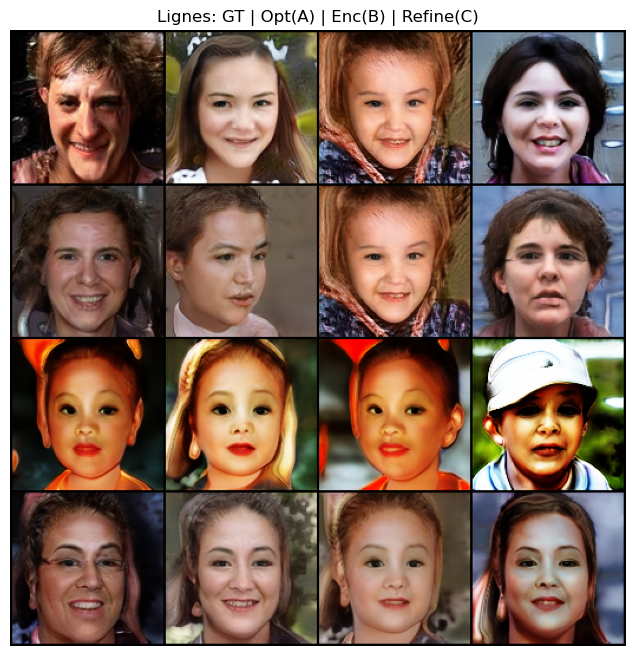

In [43]:
# metrics: PSNR, LPIPS, SSIM, or MSE in pixel/latent space.

# compare three schemes: 
# 1. direct optimization-based inversion
# 2. encoder-only $\hat z = E(x)$
# 3. encoder + refinement (few optimization steps from $E(x)$) as a warm start

import pandas as pd

# --- Configuration ---
NUM_TEST = 16
# Steps pour l'optimisation complète (A)
STEPS_OPT = 500 
# Steps pour le raffinement (C) - Doit être court pour prouver l'utilité de E
STEPS_REFINE = 100 

# 1. Création du Dataset de Test (Ground Truth)
with torch.no_grad():
    z_gt = torch.randn(NUM_TEST, Z_DIM, device=device)
    x_gt_raw, _ = G(z_gt)
    # Cible normalisée [-1, 1] pour le calcul de perte
    x_gt = x_gt_raw.clamp(-1, 1) 
    
    # Entrée pour l'encodeur (normalisation dépend de votre E, ici supposé [-1, 1])
    x_in_E = x_gt.detach() # Si votre E veut [0,1], convertissez ici

# Fonction utilitaire pour l'optimisation par batch
def optimize_batch(z_init, x_target, steps, lr=0.05):
    z_opt = z_init.clone().detach().requires_grad_(True)
    optimizer = torch.optim.Adam([z_opt], lr=lr)
    
    for i in range(steps):
        optimizer.zero_grad()
        x_rec, _ = G(z_opt)
        # Loss MSE sur les pixels [-1, 1]
        loss = F.mse_loss(x_rec, x_target)
        loss.backward()
        optimizer.step()
        
    return z_opt.detach()

# --- Exécution des 3 Méthodes ---

print("Exécution Method A: Optimization from Scratch...")
z_rand = torch.randn_like(z_gt)
z_A = optimize_batch(z_rand, x_gt, STEPS_OPT)

print("Exécution Method B: Encoder Only...")
with torch.no_grad():
    E.eval()
    z_B = E(x_in_E)

print("Exécution Method C: Encoder + Refinement...")
z_C = optimize_batch(z_B, x_gt, STEPS_REFINE) # Départ de z_B

# --- Évaluation et Métriques ---

def compute_metrics(z_pred, z_true, x_target, name):
    # Reconstruction image
    with torch.no_grad():
        x_rec, _ = G(z_pred)
        x_rec = x_rec.clamp(-1, 1)
    
    # Métriques
    mse_img = F.mse_loss(x_rec, x_target).item()
    mse_lat = F.mse_loss(z_pred, z_true).item()
    
    return {"Method": name, "MSE Image": mse_img, "MSE Latent": mse_lat}

results = []
results.append(compute_metrics(z_A, z_gt, x_gt, "A: Optimization (Scratch)"))
results.append(compute_metrics(z_B, z_gt, x_gt, "B: Encoder Only"))
results.append(compute_metrics(z_C, z_gt, x_gt, "C: Encoder + Refinement"))

# Affichage Table
df = pd.DataFrame(results)
print("\n--- Résultats Comparatifs ---")
print(df.to_string(index=False))

# --- Visualisation ---
# On affiche 4 exemples : Cible | A | B | C
with torch.no_grad():
    def to_img(z): return ((G(z)[0] + 1) / 2).clamp(0, 1)
    
    imgs_gt = ((x_gt + 1) / 2).clamp(0, 1)[:4]
    imgs_A = to_img(z_A)[:4]
    imgs_B = to_img(z_B)[:4]
    imgs_C = to_img(z_C)[:4]
    
    grid = torch.cat([imgs_gt, imgs_A, imgs_B, imgs_C], dim=0)
    # Ordre lignes : GT, A, B, C
    show_tensor_images(grid, nrow=4, title="Lignes: GT | Opt(A) | Enc(B) | Refine(C)")

__Task 2 (Bonus) — Language-controlled encoding / text-guided generation__

Use **text** to control the encoding or generation process so that you can achieve a form of **text-to-image** or **text-guided face editing**. For example: condition the encoder on a text prompt (e.g. via CLIP text embeddings) so that $E(x, \text{prompt})$ produces a latent that reconstructs or edits the face according to the prompt; or combine an encoder with a text-conditioned refinement step. You may use the provided CLIP-based setup or consider stronger / different models. The goal is to demonstrate that text can steer the latent or the reconstruction in a meaningful way.


In [ ]:
# Design your own encoder
import clip

print("Chargement du modèle CLIP...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

TEXT_PROMPT = "a man with white hair and glasses"  
LEARNING_RATE = 0.05
STEPS = 100

# 1. Initialisation
z_init = torch.randn(1, Z_DIM, device=device) 
z_edit = z_init.clone().detach().requires_grad_(True)

optimizer = torch.optim.Adam([z_edit], lr=LEARNING_RATE)

# 2. Encodage du Texte Cible 
text_inputs = clip.tokenize([TEXT_PROMPT]).to(device)
with torch.no_grad():
    target_text_features = clip_model.encode_text(text_inputs)
    target_text_features /= target_text_features.norm(dim=-1, keepdim=True)

print(f"Optimisation vers le prompt: '{TEXT_PROMPT}'...")

losses = []

# Normalisation ImageNet pour CLIP (Mean/Std)
clip_mean = torch.tensor([0.481, 0.457, 0.408], device=device).view(1,3,1,1)
clip_std  = torch.tensor([0.268, 0.261, 0.275], device=device).view(1,3,1,1)

for i in range(STEPS):
    optimizer.zero_grad()
    
    # A. Génération de l'image candidate
    img_gen_raw, _ = G(z_edit, truncation_psi=0.7)
    
    # B. Préparation pour CLIP
    img_gen = (img_gen_raw + 1) / 2
    
    # Redimensionnement différentiable vers 224x224
    img_resized = F.interpolate(img_gen, size=(224, 224), mode='bilinear', align_corners=False)
    
    # Normalisation statistique 
    img_clip_input = (img_resized - clip_mean) / clip_std
    
    # C. Encodage Image par CLIP
    img_features = clip_model.encode_image(img_clip_input)
    img_features = img_features / img_features.norm(dim=-1, keepdim=True)
    
    # D. Loss : 1 - Cosine Similarity
    loss = 1 - (img_features * target_text_features).sum()
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if i % 20 == 0:
        print(f"Iter {i}: Loss = {loss.item():.4f}")

# --- Résultats ---
with torch.no_grad():
    # Image de départ
    img_start, _ = G(z_init, truncation_psi=0.7)
    img_start = ((img_start + 1) / 2).clamp(0, 1)
    
    # Image finale optimisée
    img_end, _ = G(z_edit, truncation_psi=0.7)
    img_end = ((img_end + 1) / 2).clamp(0, 1)
    
    res = torch.cat([img_start, img_end], dim=0)
    show_tensor_images(res, nrow=2, title=f"Original -> '{TEXT_PROMPT}'")

plt.plot(losses)
plt.title("CLIP Semantic Loss")
plt.xlabel("Iterations")
plt.show()

ModuleNotFoundError: No module named 'clip'

__Task3 (Not bonus but just try it out a bit, I won't score this one): try to have fun with the Dust3r__
E.g. reconstruct 3D from two images and show the 3D.

In [ ]:
# Enjoy yourself here!